<a href="https://colab.research.google.com/github/akshathakousthubahs-tech/Seasonal-Agriculture-Performance-Analysis/blob/main/agriculture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset successfully loaded. Total rows and columns: (4000, 28)

Missing values check after median imputation:
Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64

--- SEASONAL PERFORMANCE SUMMARY ---
Season  Avg_Yield  Avg_Production   Avg_Revenue  Avg_Total_Cost  Avg_Net_Profit  Avg_Water_Efficiency  Avg_Disease_Risk_Pct
Kharif   5.630616       46.311192 710719.055649   531804.408094   178914.647555              5.891834             54.467903
  Rabi   5.094917       41.486712 601526.048556   513836.578365    87689.470191              5.186122             40.482114
  Zaid   4.637340       38.886111 519171.904040   543976.728956   -24804.824916              4.413239             38.216667


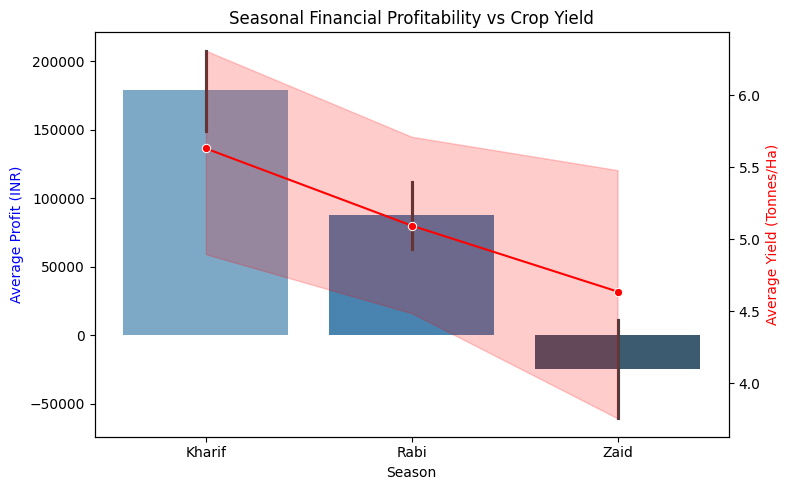


--- CROP PROFITABILITY MATRIX (INR) ---
Season         Kharif       Rabi       Zaid
Crop                                       
Chilli      954380.42  638572.50  448659.09
Cotton      216999.55  107343.59  -53925.34
Groundnut   108265.44   10416.54  -68872.50
Maize       -39332.67  -89133.40 -194049.17
Pulses       43338.90  -14309.14 -139227.81
Rice        -64903.40  -98427.87 -227239.34
Sugarcane  1000790.81  731612.86  583635.80
Wheat      -105871.87 -119954.57 -193208.95


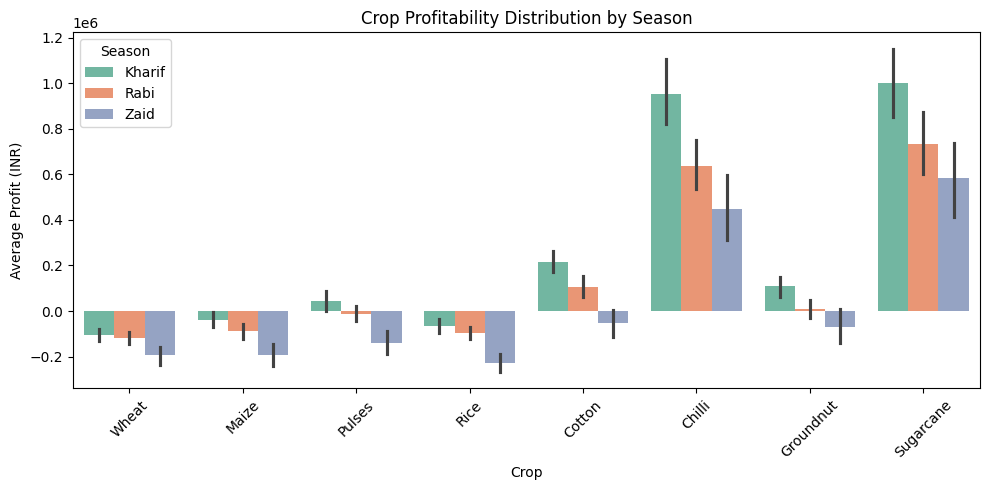


--- IRRIGATION METHOD YIELD SUMMARY (TONNES/HA) ---
Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif             7.26   4.98     5.70       4.67
Rabi               6.35   5.06     3.93       5.31
Zaid               5.85   3.97     3.06       6.14


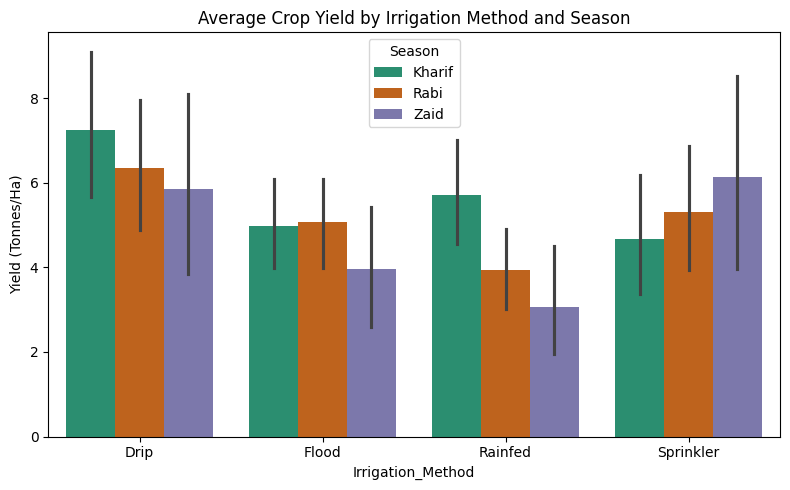


--- ENVIRONMENTAL PEST RISK & RESOURCE INPUT SUMMARY ---
        Disease_Pest_Risk_pct  Pesticide_Litre_ha  Fertilizer_kg_ha
Season                                                             
Kharif                  54.47                5.08            187.08
Rabi                    40.48                5.02            185.41
Zaid                    38.22                5.17            184.64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. ENVIRONMENT SETUP AND DATASET LOADING
filename = '/content/seasonal_agriculture_performance_dataset.csv'

# Prompt interactive upload if file is missing in current session
if not os.path.exists(filename):
    print("Dataset not found in session storage. Uploading CSV file:")
    from google.colab import files
    uploaded = files.upload()

# Load raw dataset into Pandas DataFrame
df = pd.read_csv(filename)
print("Dataset successfully loaded. Total rows and columns:", df.shape)


# 2. DATA PREPROCESSING AND MISSING VALUE IMPUTATION
# Fill missing environmental and yield values using median strategy by group
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(
    df.groupby('Season')['Rainfall_mm'].transform('median')
)
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(
    df.groupby('Season')['Soil_Moisture_pct'].transform('median')
)
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(
    df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].transform('median')
)

print("\nMissing values check after median imputation:")
print(df[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].isnull().sum())

# 3. SEASONAL AGGREGATION & PERFORMANCE METRICS
# Compute average productivity, financial, and efficiency metrics across seasons
seasonal_metrics = df.groupby('Season').agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Production=('Production_Tonnes', 'mean'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Total_Cost=('Total_Cost_INR', 'mean'),
    Avg_Net_Profit=('Profit_INR', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk_Pct=('Disease_Pest_Risk_pct', 'mean')
).reset_index()

print("\n--- SEASONAL PERFORMANCE SUMMARY ---")
print(seasonal_metrics.to_string(index=False))

# Plot dual-axis chart: Seasonal Average Profit vs. Yield
fig, ax1 = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x='Season', y='Profit_INR', ax=ax1, hue='Season', palette='Blues_d', legend=False)
ax1.set_ylabel('Average Profit (INR)', color='blue')
ax1.set_title('Seasonal Financial Profitability vs Crop Yield')

ax2 = ax1.twinx()
sns.lineplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=ax2, color='red', marker='o')
ax2.set_ylabel('Average Yield (Tonnes/Ha)', color='red')
plt.tight_layout()
plt.savefig('seasonal_profit_yield.png')
plt.show()

# 4. CROP PROFITABILITY ANALYSIS ACROSS SEASONS

# Pivot table for crop-wise average profit across seasons
crop_profitability_matrix = df.groupby(['Crop', 'Season'])['Profit_INR'].mean().unstack()

print("\n--- CROP PROFITABILITY MATRIX (INR) ---")
print(crop_profitability_matrix.round(2))

# Plot grouped bar chart comparing profitability across crops and seasons
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Crop', y='Profit_INR', hue='Season', palette='Set2')
plt.title('Crop Profitability Distribution by Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('crop_profit_season.png')
plt.show()

# 5. IRRIGATION METHOD EFFICIENCY EVALUATION

# Calculate average crop yield across different irrigation techniques
irrigation_yield_matrix = df.groupby(['Season', 'Irrigation_Method'])['Yield_Tonnes_Ha'].mean().unstack()

print("\n--- IRRIGATION METHOD YIELD SUMMARY (TONNES/HA) ---")
print(irrigation_yield_matrix.round(2))

# Plot grouped bar chart for yield comparison by irrigation type
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Irrigation_Method', y='Yield_Tonnes_Ha', hue='Season', palette='Dark2')
plt.title('Average Crop Yield by Irrigation Method and Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.savefig('irrigation_yield.png')
plt.show()

# 6. PEST RISK AND INPUT RESOURCE ANALYSIS
# Calculate average pest risk percentage, pesticide, and fertilizer usage
environmental_risk_summary = df.groupby('Season')[['Disease_Pest_Risk_pct', 'Pesticide_Litre_ha', 'Fertilizer_kg_ha']].mean()

print("\n--- ENVIRONMENTAL PEST RISK & RESOURCE INPUT SUMMARY ---")
print(environmental_risk_summary.round(2))